<a href="https://colab.research.google.com/github/alina518/Projects/blob/main/Phishing_Detector_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## Step 1 — Install Libraries

In [ ]:
# gradio    → builds the interactive web UI
# xgboost   → powerful ML model (optional, we use RandomForest here)
# tldextract → cleanly splits a URL into subdomain / domain / suffix
!pip install gradio xgboost tldextract --quiet
print('Libraries installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.4 MB/s eta 0:00:00
Libraries installed


---
## Step 2 — Import

In [ ]:
import re           # regular expressions — for pattern matching in URLs
import math         # for entropy calculation
import warnings
import requests      # to download the dataset from the internet
from io import StringIO
from urllib.parse import urlparse, parse_qs  # breaks a URL into its parts

import numpy as np               # numerical operations
import pandas as pd              # data tables (like Excel in Python)
import matplotlib.pyplot as plt  # plotting charts
import seaborn as sns            # prettier charts
import tldextract                # domain parsing

from sklearn.model_selection import train_test_split   # split data into train/test
from sklearn.ensemble import RandomForestClassifier    # our ML model
from sklearn.metrics import (
    accuracy_score,          # % of correct predictions
    classification_report,   # precision, recall, F1
    confusion_matrix,        # table of right/wrong predictions
    ConfusionMatrixDisplay   # visualise confusion matrix
)

import gradio as gr  # the UI library

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('All imports successful')

All imports successful


---
## Step 3 — URL Feature Extractor

Instead of using a dataset where features were pre-computed for us,
we write a function that extracts **30 features directly from any URL string**.

This means:
- No missing/defaulted values
- Works on any new URL at prediction time too
- Every feature has a real, meaningful value

Examples of features we extract:
| Feature | Why it matters |
|---------|----------------|
| `has_ip` | Phishing sites often use raw IPs instead of domain names |
| `url_entropy` | Fake URLs tend to have more random-looking characters |
| `has_suspicious_word` | Words like 'login', 'verify', 'secure' are common in phishing |
| `num_subdomains` | Phishing URLs often stack up subdomains |
| `is_https` | Legitimate sites usually use HTTPS |

In [ ]:
def entropy(s):
    """Shannon entropy — measures randomness of a string.
    High entropy = more random = more likely to be a generated/fake URL."""
    if not s: return 0
    freq = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in freq)


def extract_features(url):
    """Takes a URL string and returns a dictionary of 30 numeric features."""

    # Make sure the URL has a scheme so urlparse works correctly
    url = url.strip()
    if not url.startswith('http'):
        url = 'http://' + url

    # Break the URL into components
    parsed    = urlparse(url)
    ext       = tldextract.extract(url)
    hostname  = parsed.hostname or ''
    path      = parsed.path or ''
    domain    = ext.domain           # e.g. 'google'
    suffix    = ext.suffix           # e.g. 'com'
    subdomain = ext.subdomain        # e.g. 'mail' in mail.google.com
    query     = parsed.query or ''

    # ── Length-based features ──────────────────────────────
    url_len       = len(url)          # very long URLs are suspicious
    hostname_len  = len(hostname)     # long hostnames are suspicious
    path_len      = len(path)         # long paths can indicate redirects
    domain_len    = len(domain)
    subdomain_len = len(subdomain)
    tld_len       = len(suffix)       # unusual TLDs (.xyz, .ru) can be suspicious

    # ── Character count features ───────────────────────────
    # Phishing URLs often have unusual amounts of these characters
    count_dots        = url.count('.')
    count_hyphens     = url.count('-')
    count_underscores = url.count('_')
    count_slashes     = url.count('/')
    count_question    = url.count('?')
    count_equals      = url.count('=')
    count_at          = url.count('@')   # @ in URL is a classic phishing trick
    count_ampersand   = url.count('&')
    count_digits_url  = sum(c.isdigit() for c in url)
    count_digits_host = sum(c.isdigit() for c in hostname)

    # ── Domain structure features ──────────────────────────
    num_subdomains    = len(subdomain.split('.')) if subdomain else 0  # stacked subdomains = suspicious
    has_ip            = int(bool(re.match(r'^\d{1,3}(\.\d{1,3}){3}$', hostname)))  # IP instead of name
    has_hyphen_domain = int('-' in domain)   # paypal-secure.com style

    # ── Path features ─────────────────────────────────────
    path_depth       = path.count('/')        # deeply nested paths
    has_double_slash = int('//' in path)      # redirect trick

    # ── Security / protocol features ──────────────────────
    is_https           = int(parsed.scheme == 'https')  # legit sites use HTTPS
    has_port           = int(bool(parsed.port and parsed.port not in [80, 443]))  # non-standard port
    has_at_symbol      = int('@' in url)
    has_http_in_domain = int('http' in hostname)  # e.g. http.paypal.fake.com

    # ── URL shortener check ────────────────────────────────
    # Shorteners hide the real destination — common in phishing
    shorteners   = r'(bit\.ly|goo\.gl|t\.co|tinyurl|ow\.ly|is\.gd|shorte\.st|buff\.ly)'
    is_shortened = int(bool(re.search(shorteners, hostname)))

    # ── Suspicious keyword check ───────────────────────────
    # Words commonly used to trick users
    suspicious_words    = ['login','signin','verify','secure','account','update',
                           'banking','paypal','ebay','amazon','password','confirm']
    has_suspicious_word = int(any(w in url.lower() for w in suspicious_words))

    # ── Entropy (randomness) features ─────────────────────
    url_entropy    = entropy(url)     # random-looking full URL
    domain_entropy = entropy(domain)  # random-looking domain name

    # ── Query string features ──────────────────────────────
    num_params = len(parse_qs(query))  # many parameters can indicate tracking/redirect

    return {
        'url_len': url_len, 'hostname_len': hostname_len, 'path_len': path_len,
        'domain_len': domain_len, 'subdomain_len': subdomain_len, 'tld_len': tld_len,
        'count_dots': count_dots, 'count_hyphens': count_hyphens,
        'count_underscores': count_underscores, 'count_slashes': count_slashes,
        'count_question': count_question, 'count_equals': count_equals,
        'count_at': count_at, 'count_ampersand': count_ampersand,
        'count_digits_url': count_digits_url, 'count_digits_host': count_digits_host,
        'num_subdomains': num_subdomains, 'has_ip': has_ip,
        'has_hyphen_domain': has_hyphen_domain, 'path_depth': path_depth,
        'has_double_slash': has_double_slash, 'is_https': is_https,
        'has_port': has_port, 'has_at_symbol': has_at_symbol,
        'has_http_in_domain': has_http_in_domain, 'is_shortened': is_shortened,
        'has_suspicious_word': has_suspicious_word,
        'url_entropy': url_entropy, 'domain_entropy': domain_entropy,
        'num_params': num_params,
    }


# Quick test — let's see what features look like for a real URL
sample = extract_features('https://paypal.com.secure-login.xyz/verify?user=abc')
print('Sample features for a suspicious URL:')
for k, v in sample.items():
    print(f'  {k:30s}: {v}')

Sample features for a suspicious URL:
  url_len                       : 51
  hostname_len                  : 27
  path_len                      : 7
  domain_len                    : 12
  subdomain_len                 : 10
  tld_len                       : 3
  count_dots                    : 3
  count_hyphens                 : 1
  count_underscores             : 0
  count_slashes                 : 3
  count_question                : 1
  count_equals                  : 1
  count_at                      : 0
  count_ampersand               : 0
  count_digits_url              : 0
  count_digits_host             : 0
  num_subdomains                : 2
  has_ip                        : 0
  has_hyphen_domain             : 1
  path_depth                    : 1
  has_double_slash              : 0
  is_https                      : 1
  has_port                      : 0
  has_at_symbol                 : 0
  has_http_in_domain            : 0
  is_shortened                  : 0
  has_suspicious_word 

---
## Step 4 — Load the Dataset

We use a real dataset of URLs labelled as **benign** or **malicious** (phishing/malware).
We sample 10,000 of each to keep things balanced and fast.

In [ ]:
DATA_URL = 'https://raw.githubusercontent.com/incertum/cyber-matrix-ai/master/Malicious-URL-Detection-Deep-Learning/data/url_data_mega_deep_learning.csv'

print('Downloading dataset...')
try:
    df_raw = pd.read_csv(DATA_URL)
    print(f'Downloaded: {len(df_raw):,} URLs')
except Exception as e:
    print(f'Trying fallback... ({e})')
    fallback = 'https://raw.githubusercontent.com/faizann24/Using-machine-learning-to-detect-malicious-URLs/master/data/data.csv'
    df_raw = pd.read_csv(fallback)
    print(f'Fallback loaded: {len(df_raw):,} URLs')

# Show the raw label distribution
print('\nRaw label counts:')
print(df_raw['isMalicious'].value_counts()) # Changed 'label' to 'isMalicious'
df_raw.head()

Downloaded: 194,798 URLs

Raw label counts:
isMalicious
0    97399
1    97399
Name: count, dtype: int64


,url,isMalicious
0,songlyrics.com/news/riffd-the-shins-heartworms,0
1,imaging-resource.com/PRODS/olympus-e-m1-ii/oly...,0
2,gosugamers.net/lol/streams,0
3,thingiverse.com/corkyzett/collections/intlwome...,0
4,bausch.com/our-products/contact-lens-care/spec...,0


---
## Step 5 — Extract Features from URLs

We loop through every URL and run `extract_features()` on it.
This gives us a proper **feature matrix** — one row per URL, one column per feature.


In [ ]:
# Convert labels: 0 = benign (safe), 1 = malicious
df_raw = df_raw.dropna(subset=['url', 'isMalicious'])
df_raw['target'] = df_raw['isMalicious']

# Balance: take 10,000 safe and 10,000 malicious
good = df_raw[df_raw['target'] == 0].sample(10000, random_state=42)
bad  = df_raw[df_raw['target'] == 1].sample(10000, random_state=42)
df_balanced = pd.concat([good, bad]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Working with {len(df_balanced):,} URLs (balanced 50/50)')

# Extract features for every URL
feature_rows = []
for i, row in df_balanced.iterrows():
    try:
        f = extract_features(row['url'])
        f['target'] = row['target']
        feature_rows.append(f)
    except:
        pass  # skip malformed URLs
    if len(feature_rows) % 4000 == 0 and len(feature_rows) > 0:
        print(f'  {len(feature_rows):,} / {len(df_balanced):,} done...')

df_features = pd.DataFrame(feature_rows)
print(f'\nFeature matrix shape: {df_features.shape}  ({df_features.shape[1]-1} features x {df_features.shape[0]} URLs)')
df_features.head()

Working with 20,000 URLs (balanced 50/50)
  4,000 / 20,000 done...
  8,000 / 20,000 done...
  12,000 / 20,000 done...
  16,000 / 20,000 done...

Feature matrix shape: (19997, 31)  (30 features x 19997 URLs)


,url_len,hostname_len,path_len,domain_len,subdomain_len,tld_len,count_dots,count_hyphens,count_underscores,count_slashes,...,is_https,has_port,has_at_symbol,has_http_in_domain,is_shortened,has_suspicious_word,url_entropy,domain_entropy,num_params,target
0,21,9,0,9,0,0,3,0,0,2,...,0,1,0,0,0,0,3.558519,2.419382,0,1
1,106,8,77,4,0,3,1,0,1,8,...,0,0,0,0,0,0,4.793321,0.811278,1,0
2,94,17,56,11,0,5,2,6,1,6,...,0,0,0,0,0,0,4.722462,3.095795,0,0
3,146,21,34,17,0,3,2,4,3,4,...,0,0,0,0,0,0,4.569139,3.616875,3,0
4,95,26,62,23,0,2,2,2,0,9,...,0,0,0,0,0,0,4.299774,3.588354,0,1


---
## Step 6 — Exploratory Data Analysis (EDA)


### 6a — Class Distribution

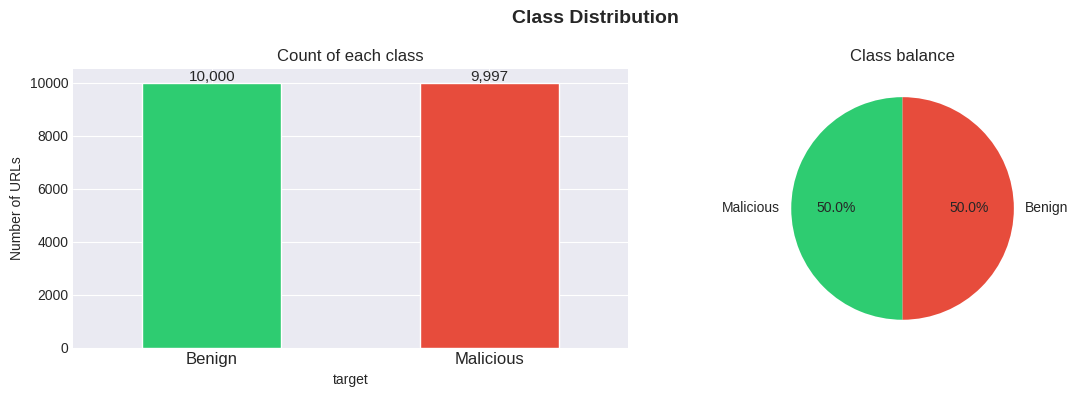

The dataset is balanced — important for fair training!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
counts = df_features['target'].value_counts().rename({0: 'Benign', 1: 'Malicious'})
counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_xticklabels(['Benign', 'Malicious'], rotation=0, fontsize=12)
axes[0].set_title('Count of each class')
axes[0].set_ylabel('Number of URLs')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class balance')

plt.tight_layout()
plt.show()
print('The dataset is balanced — important for fair training!')

### 6b — Feature Distributions: Benign vs Malicious
Compare how key features differ between safe and malicious URLs.

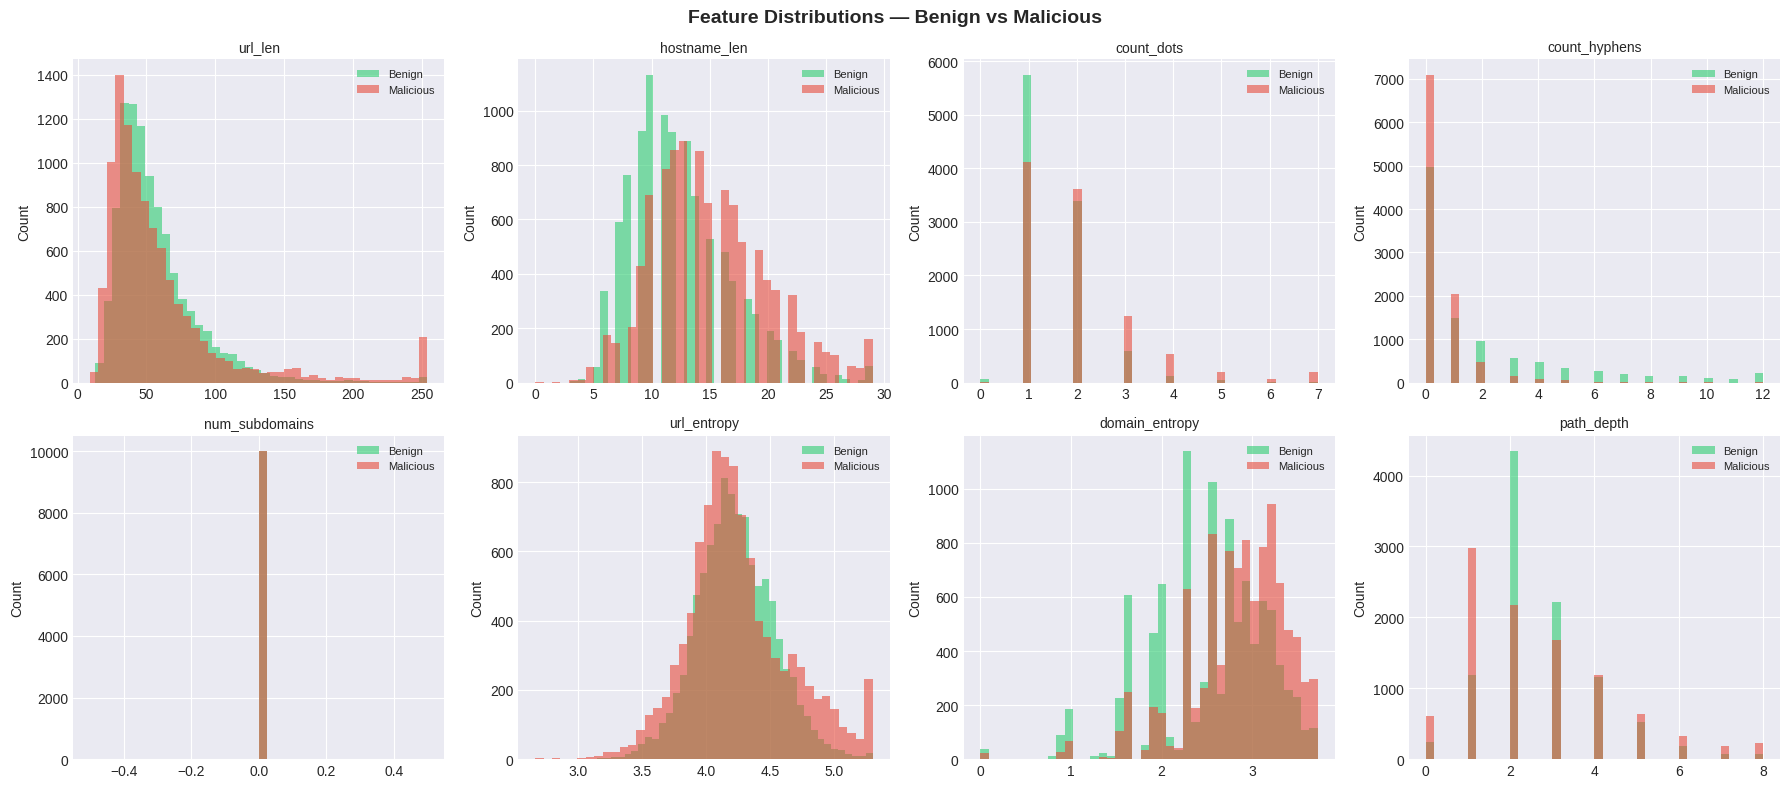

Where the distributions differ a lot → that feature is useful for the model!


In [ ]:
# Pick the most interesting features to visualise
features_to_plot = ['url_len', 'hostname_len', 'count_dots', 'count_hyphens',
                     'num_subdomains', 'url_entropy', 'domain_entropy', 'path_depth']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions — Benign vs Malicious', fontsize=14, fontweight='bold')
axes = axes.flatten()

benign    = df_features[df_features['target'] == 0]
malicious = df_features[df_features['target'] == 1]

for i, feat in enumerate(features_to_plot):
    # Clip extreme outliers for cleaner plots
    p99 = df_features[feat].quantile(0.99)
    axes[i].hist(benign[feat].clip(upper=p99),    bins=40, alpha=0.6, color='#2ecc71', label='Benign')
    axes[i].hist(malicious[feat].clip(upper=p99), bins=40, alpha=0.6, color='#e74c3c', label='Malicious')
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('Where the distributions differ a lot → that feature is useful for the model!')

### 6c — Binary Feature Rates
For yes/no features, let's see how often each is true for malicious vs benign URLs.

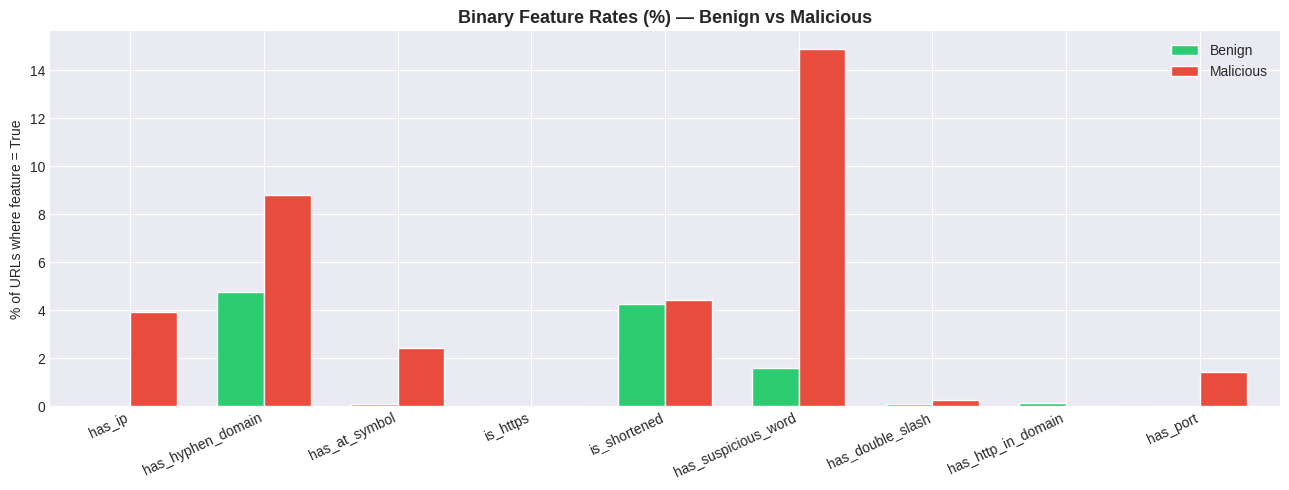

In [ ]:
binary_features = ['has_ip', 'has_hyphen_domain', 'has_at_symbol', 'is_https',
                    'is_shortened', 'has_suspicious_word', 'has_double_slash',
                    'has_http_in_domain', 'has_port']

# Compute % true for each class
rates = pd.DataFrame({
    'Benign':    benign[binary_features].mean() * 100,
    'Malicious': malicious[binary_features].mean() * 100
})

rates.plot(kind='bar', figsize=(13, 5), color=['#2ecc71', '#e74c3c'],
           edgecolor='white', width=0.7)
plt.title('Binary Feature Rates (%) — Benign vs Malicious', fontsize=13, fontweight='bold')
plt.ylabel('% of URLs where feature = True')
plt.xticks(rotation=25, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 6d — Correlation Heatmap
Which features are correlated with each other — and which correlate most with the target label?

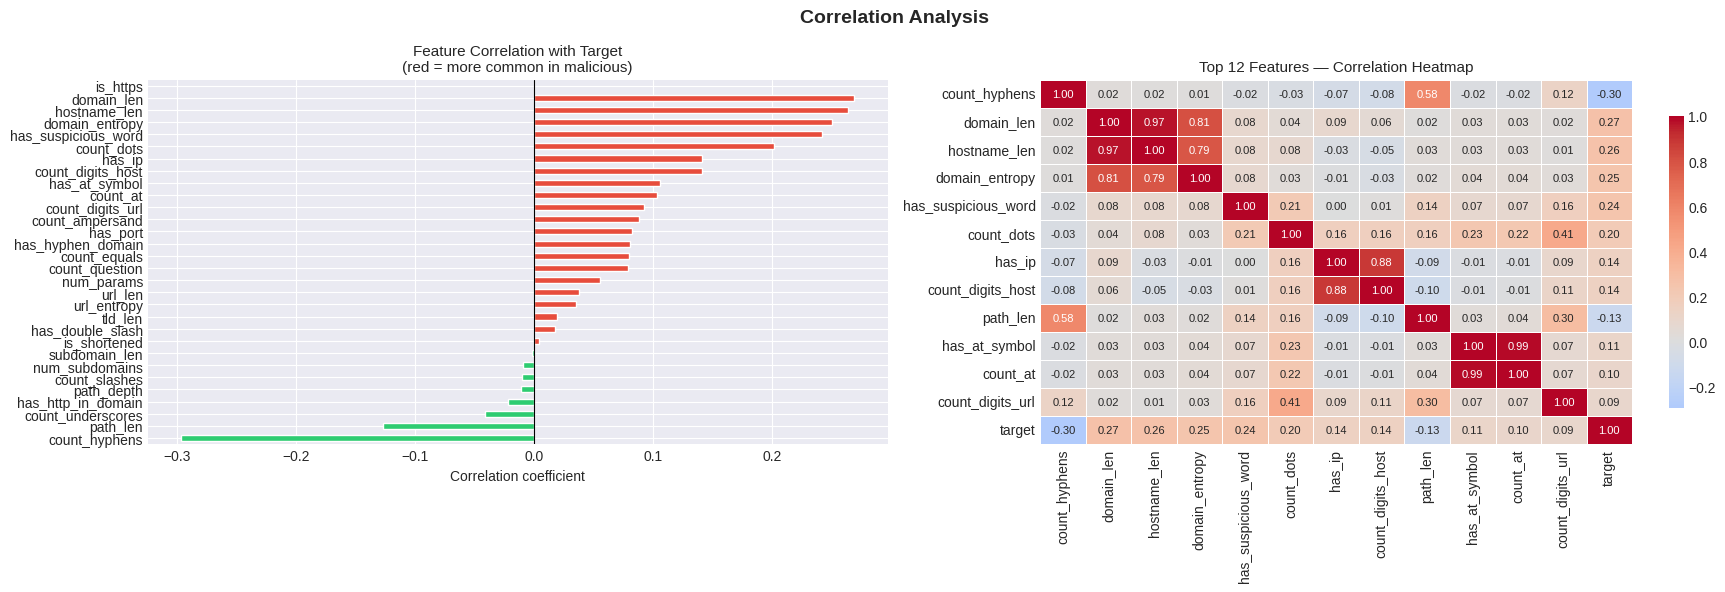

In [ ]:
# Compute correlation of all features with the target
corr_with_target = df_features.corr()['target'].drop('target').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

# Left: correlation of each feature with target
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Feature Correlation with Target\n(red = more common in malicious)', fontsize=11)
axes[0].set_xlabel('Correlation coefficient')
axes[0].axvline(0, color='black', linewidth=0.8)

# Right: heatmap of feature inter-correlations
top_feats = corr_with_target.abs().nlargest(12).index.tolist() + ['target']
sns.heatmap(df_features[top_feats].corr(), ax=axes[1], cmap='coolwarm',
            center=0, annot=True, fmt='.2f', linewidths=0.4,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
axes[1].set_title('Top 12 Features — Correlation Heatmap', fontsize=11)

plt.tight_layout()
plt.show()

---
## Step 7 — Split Data into Train & Test Sets

- **Training set (80%)** — model learns from this
- **Test set (20%)** — we evaluate on this (model has never seen it)


In [ ]:
X = df_features.drop('target', axis=1)  # features (inputs)
y = df_features['target']               # labels (outputs: 0=safe, 1=malicious)
feature_cols = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% for testing
    random_state=42,   # reproducibility
    stratify=y         # keep 50/50 balance in both sets
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')

Training samples : 15,997
Test samples     : 4,000


---
## Step 8 — Train the Random Forest Model

A **Random Forest** builds 100 decision trees, each asking questions like:
> *'Is the URL longer than 75 chars AND has no HTTPS?'*


In [ ]:
print('Training Random Forest (100 trees)...')
model = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees
    random_state=42,   # reproducibility
    n_jobs=-1          # use all CPU cores
)
model.fit(X_train, y_train)  # ← this is where learning happens
print('Training done!')

Training Random Forest (100 trees)...
Training done!


---
## Step 9 — Evaluate the Model

Key metrics:
- **Accuracy** — overall % correct
- **Precision** — of URLs flagged as malicious, how many actually were?
- **Recall** — of all malicious URLs, how many did we catch?
- **F1** — balance between precision and recall

Accuracy: 86.48%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.86      0.86      0.86      2000
   Malicious       0.86      0.86      0.86      2000

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000



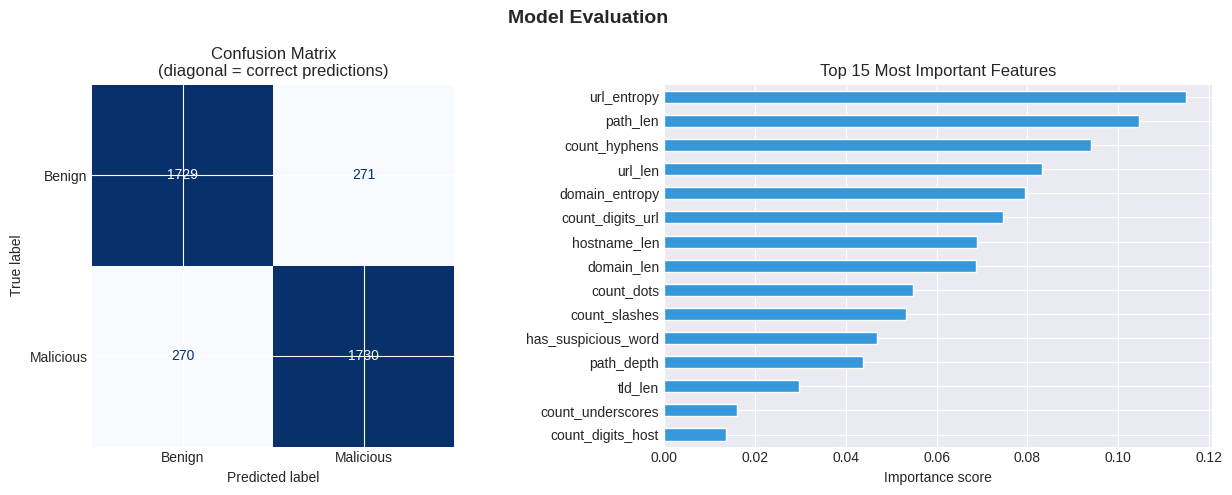

In [ ]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
acc     = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc*100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# Left: confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malicious']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(diagonal = correct predictions)')

# Right: feature importance
imp = pd.Series(model.feature_importances_, index=feature_cols).nlargest(15).sort_values()
imp.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Top 15 Most Important Features')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

---
## Step 10 — Launch the Gradio App

Now we wrap everything into an interactive web UI.
The `share=True` flag gives you a **public link** you can share with anyone!

In [ ]:
def predict(url):
    """Takes a URL string, extracts features, runs the model, returns result."""
    if not url.strip():
        return 'Please enter a URL', ''
    try:
        # 1. Extract features from the URL
        feats = extract_features(url.strip())

        # 2. Convert to DataFrame (model expects this format)
        X_url = pd.DataFrame([feats])[feature_cols]

        # 3. Predict
        pred  = model.predict(X_url)[0]
        proba = model.predict_proba(X_url)[0]  # [P(benign), P(malicious)]

        # 4. Format output
        label      = 'MALICIOUS / PHISHING' if pred == 1 else 'LEGITIMATE / SAFE'
        confidence = f'Safe: {proba[0]*100:.1f}%   |   Malicious: {proba[1]*100:.1f}%'
        return label, confidence
    except Exception as e:
        return f'Error processing URL: {e}', ''


# Build the Gradio interface
demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        label='Enter a URL to check',
        placeholder='e.g. https://www.google.com'
    ),
    outputs=[
        gr.Textbox(label='Result'),
        gr.Textbox(label='Confidence Scores'),
    ],
    title='Phishing Website Detector',


    theme=gr.themes.Soft()
)

# share=True → generates a public link valid for 72 hours
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4c1b47b008d475b09.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
